<a href="https://colab.research.google.com/github/wisesprout/project1_vgames/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames2.csv', index_col = 0)
df.head()
df = df.dropna()  # na 값 있는 데이터 제외

# 1. preprocessing vgames2
1 - 1) Publisher 전처리

In [2]:
df['Publisher'].unique()
pd.set_option('display.max_rows', None)  # value_counts 모든 값
df['Publisher'].value_counts()  # 99개의 'Unknown' 값 확인
df[df['Publisher']=='Unknown']  # 결과를 조사해보니 'Unknown Wordls Entertainment'가 아님을 확인
df.drop(df[df['Publisher']=='Unknown'].index, inplace = True)
df[df['Publisher']=='Unknown']  # drop한 결과 확인

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales


1 - 2) Year 전처리

In [3]:
# Year 정리

# df['Year'] = df['Year'].astype(int) 이건 왜 안되고 밑줄은 되지???
df.Year = df.Year.astype(int)
# Year가 4자리 아니면 drop
i = 0
while i < len(df['Year']):
    digit = 0
    year = df.iloc[i,2]
    while(year > 0):  # 10으로 계속 나눠서 자릿수 확인
        digit += 1
        year //= 10
    if digit != 4:
        df.drop(df.index[i], inplace = True)
    else:
        i += 1

df['Year'].unique()  # drop한 결과 확인

array([2008, 2009, 2010, 2005, 2011, 2007, 2001, 2003, 2006, 2014, 2015,
       2002, 1997, 2013, 1996, 2004, 2000, 1984, 1998, 2016, 1985, 1999,
       1995, 1993, 2012, 1987, 1982, 1994, 1990, 1992, 1991, 1983, 1988,
       1981, 1989, 1986, 2017, 1980, 2020])

1 - 3) Sales 단위 10,000으로 통일

In [4]:
# 단위 10,000으로 통일
for j in range(5,9):
  # j번째 컬럼의 단위를 숫자로 변경
  for i in range(len(df.iloc[:,j])):
    if ('K' in df.iloc[i,j]):  # j번째 컬럼의 i번째 값이 K를 포함하면
      df.iloc[i,j] = float(df.iloc[i,j].replace('K',''))/10**3  # K 삭제, 10^3으로 나누기, str->float
    elif ('M' in df.iloc[i,j]):  # j번째 컬럼의 i번째 값이 M을 포함하면
      df.iloc[i,j] = float(df.iloc[i,j].replace('M',''))  # M 삭제, str->float
    else:
      df.iloc[i,j] = float(df.iloc[i,j])  # K, M 없는 값은 str->float
  df.iloc[:,j] = (df.iloc[:,j]*100).astype(int)  # j번째 컬럼 전체 float->int

1 - 4) Outlier 인덱스 제거

In [5]:
# 2017, 2020년도 세일 합이 매우 적음 -> 제거
df.drop(df[(df['Year'] == 2017) | (df['Year'] == 2020)].index, inplace = True)
df.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_a.xlsx', index = False)

In [6]:
# 나머지 feature 값 확인
df['Platform'].value_counts()
df['Genre'].value_counts()
df['Genre'].unique()

array(['Action', 'Adventure', 'Misc', 'Platform', 'Sports', 'Simulation',
       'Racing', 'Role-Playing', 'Puzzle', 'Strategy', 'Fighting',
       'Shooter'], dtype=object)

# 2. 지역에 따라 선호하는 장르가 다를까?

2 - 1) 장르별 판매량 데이터프레임 생성

In [7]:
# 전체 데이터에서 지역별 장르의 출고량 데이터 추출
df2 = df[['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
# g_s = genre by sales
g_s = df2.groupby(by=['Genre']).sum()
g_s.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_gs.xlsx')
g_s

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,85411,51158,15462,18346
Adventure,10092,6324,5137,1661
Fighting,21998,9962,8633,3607
Misc,39298,20682,10357,7236
Platform,44224,19914,12920,5108
Puzzle,12068,5014,5612,1236
Racing,35332,23293,5499,7588
Role-Playing,30557,17575,33467,5452
Shooter,57045,30702,3732,10075


In [8]:
# g_s_t = tidy of g_s
g_s_t = g_s.reset_index()
g_s_t = pd.melt(g_s_t, id_vars = ['Genre'], 
                        value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
                        var_name = 'Sale_Area',
                        value_name = 'Sale_Total')
g_s_t.head()

,Genre,Sale_Area,Sale_Total
0,Action,NA_Sales,85411
1,Adventure,NA_Sales,10092
2,Fighting,NA_Sales,21998
3,Misc,NA_Sales,39298
4,Platform,NA_Sales,44224


In [9]:
g_s_t.sort_values(by = ['Sale_Area','Sale_Total'], ascending = [True, False], inplace = True)
g_s_t

,Genre,Sale_Area,Sale_Total
12,Action,EU_Sales,51158
22,Sports,EU_Sales,36942
20,Shooter,EU_Sales,30702
18,Racing,EU_Sales,23293
15,Misc,EU_Sales,20682
16,Platform,EU_Sales,19914
19,Role-Playing,EU_Sales,17575
21,Simulation,EU_Sales,11253
14,Fighting,EU_Sales,9962
13,Adventure,EU_Sales,6324


In [10]:
# 지역별 top 5 장르 내림차순
na_top = g_s_t[g_s_t['Sale_Area']=='NA_Sales'].iloc[0:5,[0,2]]
eu_top = g_s_t[g_s_t['Sale_Area']=='EU_Sales'].iloc[0:5,[0,2]]
jp_top = g_s_t[g_s_t['Sale_Area']=='JP_Sales'].iloc[0:5,[0,2]]
ot_top = g_s_t[g_s_t['Sale_Area']=='Other_Sales'].iloc[0:5,[0,2]]
na_top

,Genre,Sale_Total
0,Action,85411
10,Sports,66306
8,Shooter,57045
4,Platform,44224
3,Misc,39298


2 - 2) Pie chart를 이용한 시각화

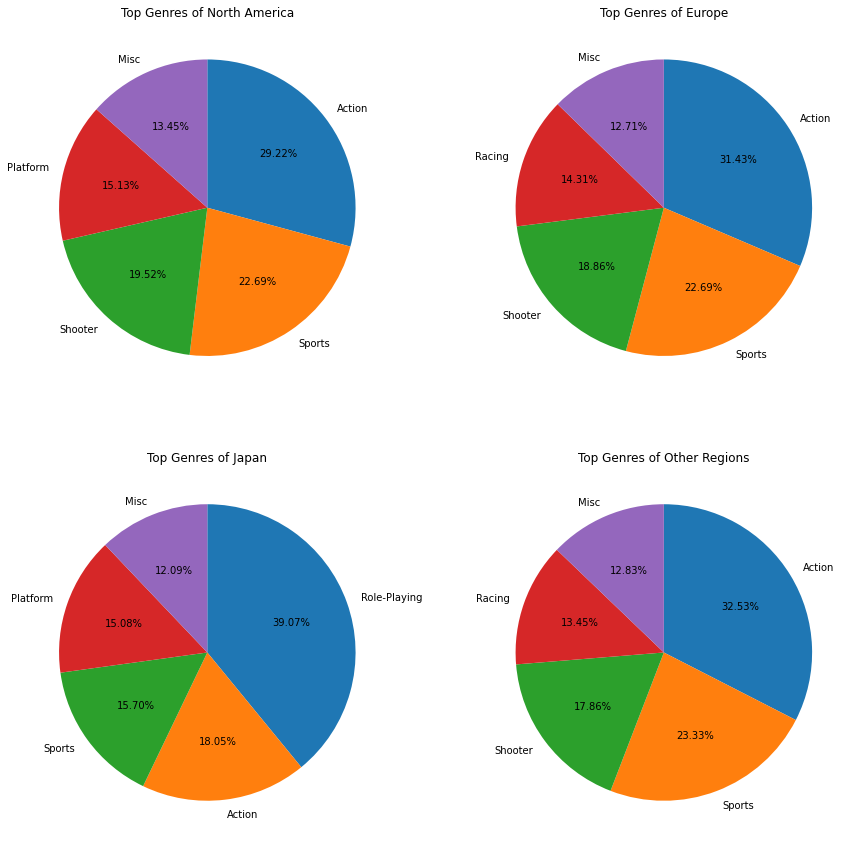

In [11]:
# 시각화 - pie chart
fig = plt.figure(figsize = (15,15))  # 배경
fig.set_facecolor('white')
#colors = sns.color_palette('hls', len(g_s_t['Genre']))

# Top 5 Genres of NA_Sales
ax = plt.subplot(221)  # 기본 위치
ax.pie(x = na_top['Sale_Total'],
       labels = na_top['Genre'],
       #colors = colors,
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of North America')

# Top 5 Genres of EU_Sales
ax = plt.subplot(222)  # 기본 위치
ax.pie(x = eu_top['Sale_Total'], 
       labels = eu_top['Genre'], 
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of Europe')

# Top 5 Genres of JP_Sales
ax = plt.subplot(223)  # 기본 위치
ax.pie(x = jp_top['Sale_Total'], 
       labels = jp_top['Genre'],
       #colors = colors,
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of Japan')

# Top 5 Genres of Other_Sales
ax = plt.subplot(224)  # 기본 위치
ax.pie(x = ot_top['Sale_Total'], 
       labels = ot_top['Genre'], 
       autopct = lambda x : '{:.2f}%'.format(x),
       startangle = 90,
       counterclock = False)
plt.title('Top Genres of Other Regions')
plt.show()

2- 3) 결론


*   북미, 유럽, 기타 지역에선 선호하는 장르 상위 5개 중 1,2,3,5위가 일치
*   일본 지역은 타 지역들보다 롤플레잉을 선호



# 3. 연도별 게임의 트렌드가 있을까?

3 - 1) 연도별 장르, 플랫폼 출고량 데이터프레임 생성

In [12]:
# 전체 데이터에서 연도, 장르, 플랫폼 추춯
df3 = df[['Year', 'Genre', 'Platform', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
df3 = df3.sort_values(by = 'Year')
df3['Sales_Sum'] = df3['NA_Sales'] + df3['EU_Sales'] + df3['JP_Sales'] + df3['Other_Sales']
df3 = df3.set_index('Year')
df3.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_df3.xlsx')
df3.head()

,Genre,Platform,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Sales_Sum
Year,,,,,,,
1980,Action,2600,32,2,0,0,34
1980,Shooter,2600,400,26,0,5,431
1980,Fighting,2600,72,4,0,1,77
1980,Misc,2600,99,5,0,1,105
1980,Shooter,2600,256,17,0,3,276


In [13]:
# 연도별 장르 출고량 데이터프레임
# y_g = year by genre
y_g = df3.drop(df3[['Platform', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']], axis = 1)
y_g = y_g.reset_index()
y_g = pd.pivot_table(y_g, index = 'Year', columns = 'Genre', values= 'Sales_Sum', aggfunc = np.sum)
y_g = y_g.fillna(0).astype(int)
y_g.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_yg.xlsx')
y_g.head()

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Year,,,,,,,,,,,,
1980,34,0,77,270,0,0,0,0,707,0,0,0
1981,1449,0,0,0,692,225,48,0,1002,44,78,0
1982,647,0,0,87,503,1004,157,0,380,0,106,0
1983,286,40,0,214,693,78,0,0,49,0,320,0
1984,185,0,0,145,69,314,595,0,3110,0,617,0


In [14]:
# 연도별 플랫폼 출고량 데이터프레임
# y_p  = year by platform
y_p = df3.drop(df3[['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']], axis = 1)
y_p = y_p.reset_index()
y_p = pd.pivot_table(y_p, index = 'Year', columns = 'Platform', values= 'Sales_Sum', aggfunc = np.sum)
y_p = y_p.fillna(0).astype(int)
y_p.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_yp.xlsx')
y_p.head()

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,N64,NES,NG,PC,PCFX,PS,PS2,PS3,PS4,PSP,PSV,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1980,1088,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1981,3538,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1982,2884,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1983,584,0,0,0,0,0,0,0,0,0,0,1096,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1984,27,0,0,0,0,0,0,0,0,0,0,5008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


3 - 2) Heatmap을 이용한 시각화

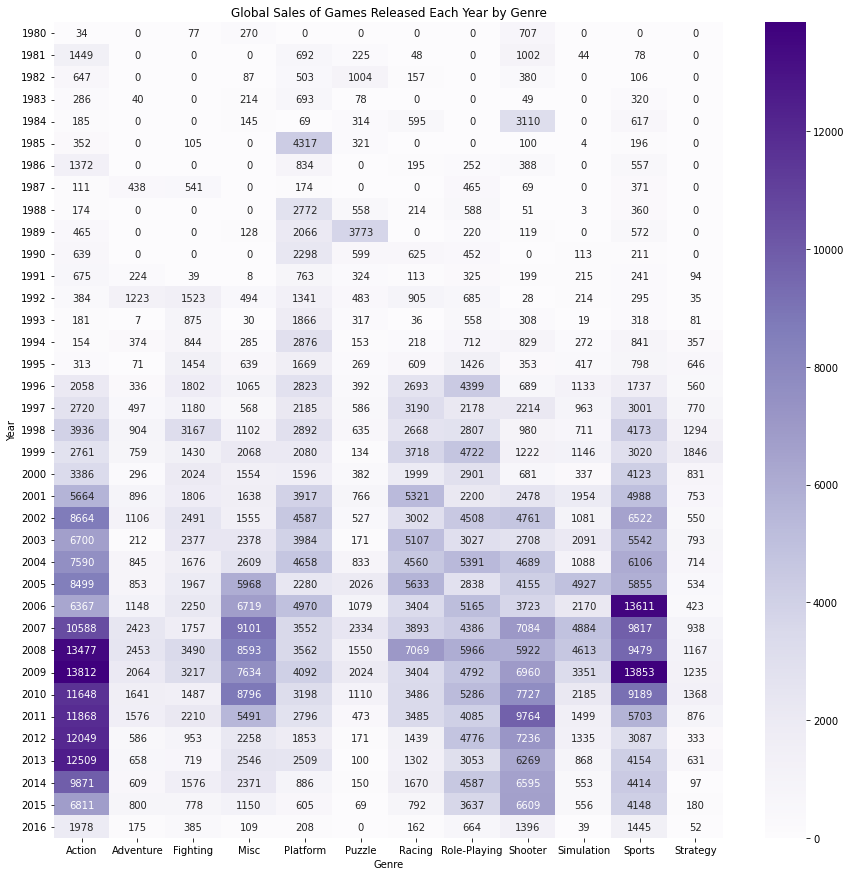

In [15]:
# 연도별 장르 출고량 시각화
plt.figure(figsize = (15, 15))
sns.heatmap(y_g, cmap = 'Purples', annot = True, fmt = 'd')
plt.xlabel('Genre')
plt.ylabel('Year')
plt.title('Global Sales of Games Released Each Year by Genre')
plt.show()

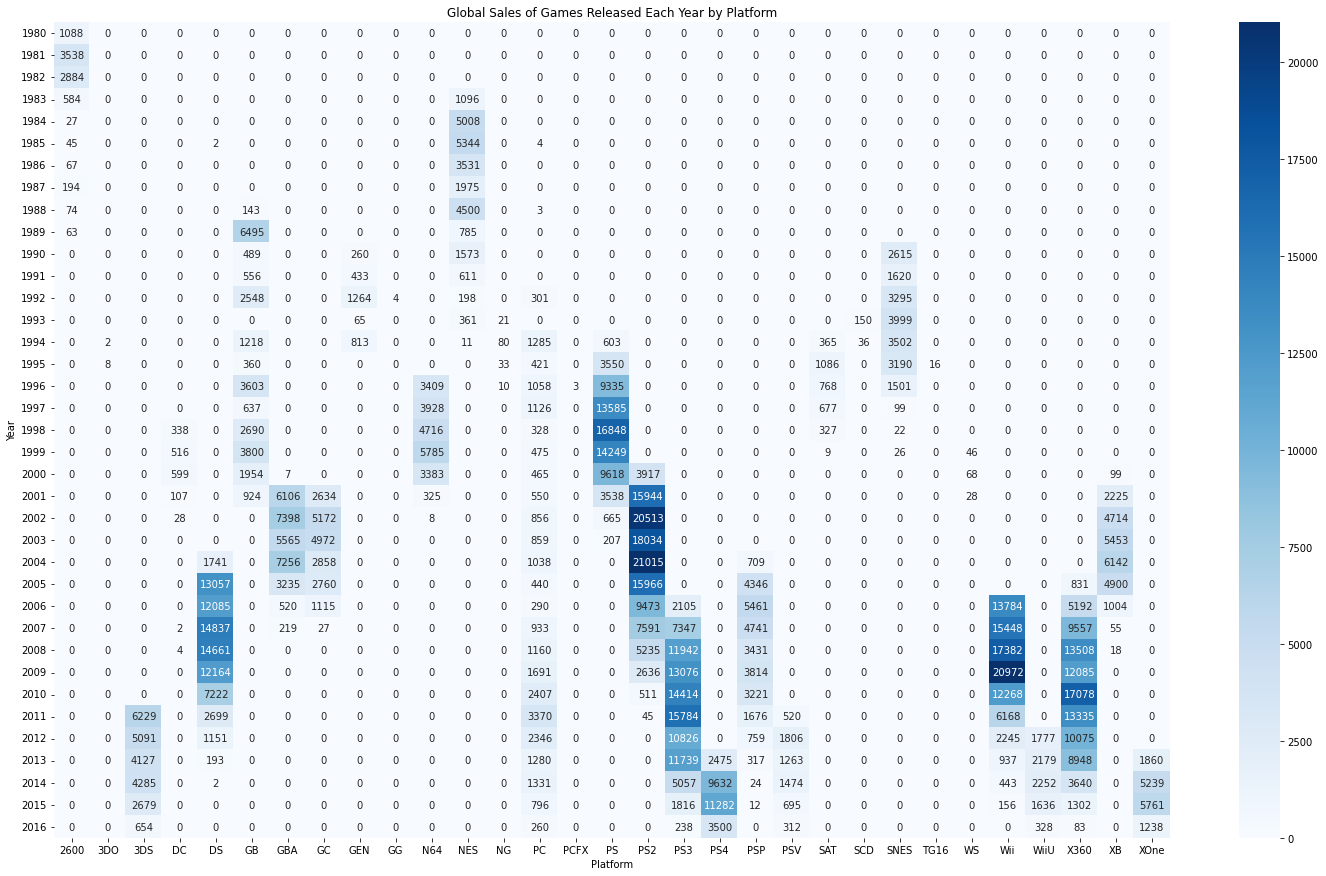

In [16]:
# 연도별 플랫폼 출고량 시각화
plt.figure(figsize = (25, 15))
sns.heatmap(y_p, cmap = 'Blues', annot = True, fmt = 'd')
plt.xlabel('Platform')
plt.ylabel('Year')
plt.title('Global Sales of Games Released Each Year by Platform')
plt.show()

3- 3) 결론


*   연도별 장르의 트렌드
     - 1980년대 - platform, shooter, puzzle
     - 1990년대 - fighting, platform
     - 2000년대 - action, sports
     - 2010년대 - action > shooter > sports, role-playing
*   연도별 플랫폼의 출고량
     - 1980년대 - 2600 -> NES
     - 1990년대 전반 - SNES > GB > GEN
     - 1990년대 후반 - PS > N64 > GB
     - 2000년대 전반 - PS2 > GBA > GC, XBOX
     - 2000년대 후반 - Wii > DS > PS3, X360
     - 2010년대 - PS3 -> PS4 > X360, 3DS

# 4. 출고량이 높은 게임에 대한 분석 및 시각화 프로세스

In [35]:
df4 = df
df4['All_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
df4.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,All_Sales
1,Candace Kane's Candy Factory,DS,2008,Action,Destineer,4,0,0,0,4
2,The Munchables,Wii,2009,Action,Namco Bandai Games,17,0,0,1,18
3,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010,Adventure,Alchemist,0,0,2,0,2
4,Deal or No Deal: Special Edition,DS,2010,Misc,Zoo Games,4,0,0,0,4
5,Ben 10 Ultimate Alien: Cosmic Destruction,PS3,2010,Platform,D3Publisher,12,9,0,4,25


In [40]:
df4 = df4.sort_values(by = 'All_Sales', ascending = False)
df4 = df4.iloc[0:100, :]
df4

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,All_Sales
2909,Wii Sports,Wii,2006,Sports,Nintendo,4149,2902,377,846,8274
4200,Super Mario Bros.,NES,1985,Platform,Nintendo,2908,358,681,77,4024
12580,Mario Kart Wii,Wii,2008,Racing,Nintendo,1585,1288,379,331,3583
3353,Wii Sports Resort,Wii,2009,Sports,Nintendo,1575,1101,328,296,3300
7830,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,1127,889,1022,100,3138
1204,Tetris,GB,1989,Puzzle,Nintendo,2320,225,422,57,3024
6938,New Super Mario Bros.,DS,2006,Platform,Nintendo,1138,923,650,290,3001
3015,Wii Play,Wii,2006,Misc,Nintendo,1403,919,293,285,2900
16532,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,1459,706,470,225,2860
10489,Duck Hunt,NES,1984,Shooter,Nintendo,2693,63,28,47,2831


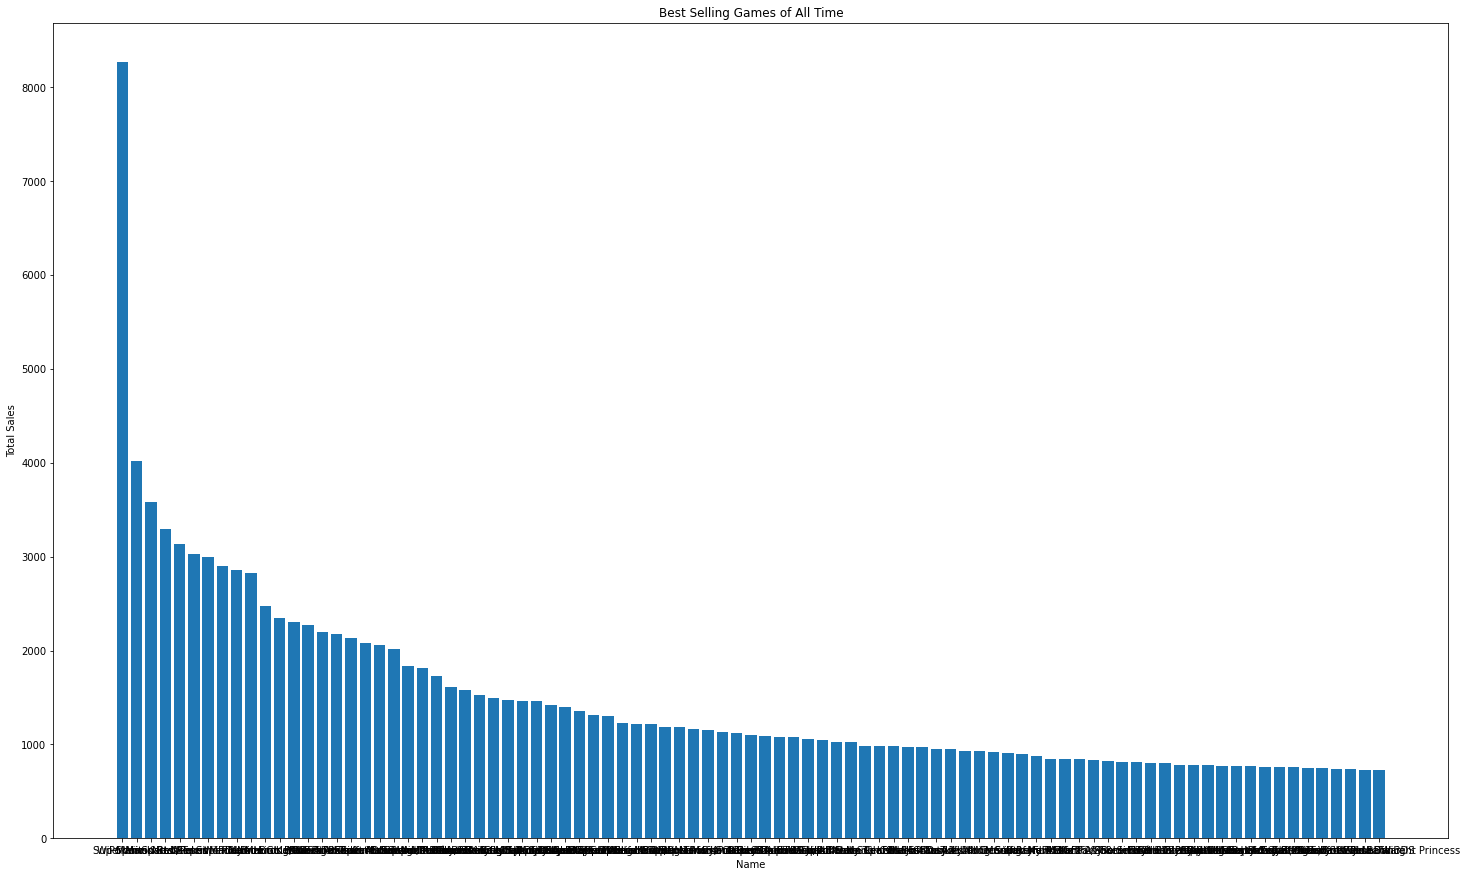

In [47]:
plt.figure(figsize = (25, 15))
plt.bar(df4['Name'], df4['All_Sales'])
plt.title('Best Selling Games of All Time')
plt.xlabel('Name')
plt.ylabel('Total Sales')
plt.show()

In [39]:
df4.head(10)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,All_Sales
2909,Wii Sports,Wii,2006,Sports,Nintendo,4149,2902,377,846,8274
4200,Super Mario Bros.,NES,1985,Platform,Nintendo,2908,358,681,77,4024
12580,Mario Kart Wii,Wii,2008,Racing,Nintendo,1585,1288,379,331,3583
3353,Wii Sports Resort,Wii,2009,Sports,Nintendo,1575,1101,328,296,3300
7830,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,1127,889,1022,100,3138
1204,Tetris,GB,1989,Puzzle,Nintendo,2320,225,422,57,3024
6938,New Super Mario Bros.,DS,2006,Platform,Nintendo,1138,923,650,290,3001
3015,Wii Play,Wii,2006,Misc,Nintendo,1403,919,293,285,2900
16532,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,1459,706,470,225,2860
10489,Duck Hunt,NES,1984,Shooter,Nintendo,2693,63,28,47,2831
